## FLAG-X workflow, labeled data

This notebook demonstrates how FLAG-X can be used for fully automated gating of multiple samples using MLP and SOM classifier. It further illustrates how dimensionality reductions FCS export can be used to improve imperfect ground truth training labels. For details, refer to our preprint on [bioRxiv](https://doi.org/10.64898/2026.01.10.698765).

For demonstration purposes, only six samples from the BLAST110 dataset published by Mocking *et al.* (2025) (see [DOI](https://doi.org/10.1038/s43856-024-00700-x), [Zenodo](https://zenodo.org/records/11046402)) are used to demonstrate the following workflow:

1. Data loading
2. Data processing
3. Classifier training
4. Inference
5. Export
6. Feedback loop [optional]

**Disclaimer**: This notebook is intended as a template for adopting FLAG-X workflows to new datasets. The generated results are illustrative and should not be interpreted as a rigorous evaluation.

### Import packages and define paths

In [345]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

from sklearn.metrics import precision_score, recall_score, f1_score
from flagx.io import FlowDataManager, export_to_fcs
from flagx.io.io_utils import get_labels
from flagx.gating import MLPClassifier, SOMClassifier
from flagx.dimred import UMAP, TSNE

plt.style.use('default')

BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data')
SAVE_PATH = os.path.join(BASE_DIR, 'results')
os.makedirs(SAVE_PATH, exist_ok=True)


### 1.) Data loading

Load the *FCS* files corresponding to patient samples using FLAG-X's ``FlowDataManager`` class.

Supported file formats are:
- *CSV*
- *FCS*, versions **3.1**, **3.0**, **2.0**
- *LMD*, containing an *FCS3.1*, *FCS3.0*, or *FCS2.0*-compliant part

Harmonization of channel names and channel ordering is only partially handled by FLAG-X and must be performed manually. Each sample is expected to contain the same number of channels, in the same order, corresponding to the same markers.

For further details please refer to the [docs](https://flag-x.readthedocs.io/en/latest/).

In [346]:

# Get the data filenames
data_filenames = sorted([fn for fn in os.listdir(DATA_PATH) if fn.endswith('.fcs')])

# Instantiate the FlowDataManager
fdm = FlowDataManager(
    data_file_names=data_filenames,
    data_file_path=DATA_PATH,
    save_path=SAVE_PATH,
    verbosity=0
)

# Load the datafiles into memory; If present, use marker names (PnS) as index.
fdm.load_data_files_to_anndata(reindex=True)

# Harmonize channel names and order
mapping = {'CD34 Cy55': 'CD34', 'CD45 KO': 'CD45'}
for adata in fdm.anndata_list_:
    adata.var.index = adata.var.index.map(lambda x: mapping.get(x, x))
    spill = adata.uns['meta']['spill']
    spill.index = spill.index.to_series().replace(mapping)
    spill.columns = spill.columns.to_series().replace(mapping)
    adata.uns['meta']['spill'] = spill
common_channels = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']
for i, adata in enumerate(fdm.anndata_list_):
    fdm.anndata_list_[i] = adata[:, common_channels].copy()


### Labeled data curation
The output of manual gating typically consists of multiple *CSV* files per sample corresponding to a specific subpopulation. By reconcatenating those population files and adding a label column, one can curate an annotated dataset for supervised classifier training. Here, the labels are provided by Mocking *et al.* (2025) ([Zenodo](https://zenodo.org/records/11046402), [DOI](https://doi.org/10.1038/s43856-024-00700-x)). Thus, simply appending them to the loaded data suffices.

In [347]:
# Iterate over data samples, load labels, and add labels
for i, adata in enumerate(fdm.anndata_list_):
    label_df = pd.read_csv(os.path.join(DATA_PATH, adata.uns['filename'][:-4] + '.csv'), index_col=0)

    # Add event IDs from data matrix to obs
    event_ids = adata[:, 'event_ID'].X.flatten().astype(int).tolist()
    adata.obs['event_ID'] = event_ids

    # Merge dataframes
    new_obs = adata.obs.merge(label_df, on='event_ID', how='left')
    new_obs.index = new_obs.index.astype(str)

    # Update obs
    adata.obs = new_obs

    fdm.anndata_list_[i] = adata.copy()


### 3.) Data processing

# Channel names:
['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45', 'Time', 'event_ID']



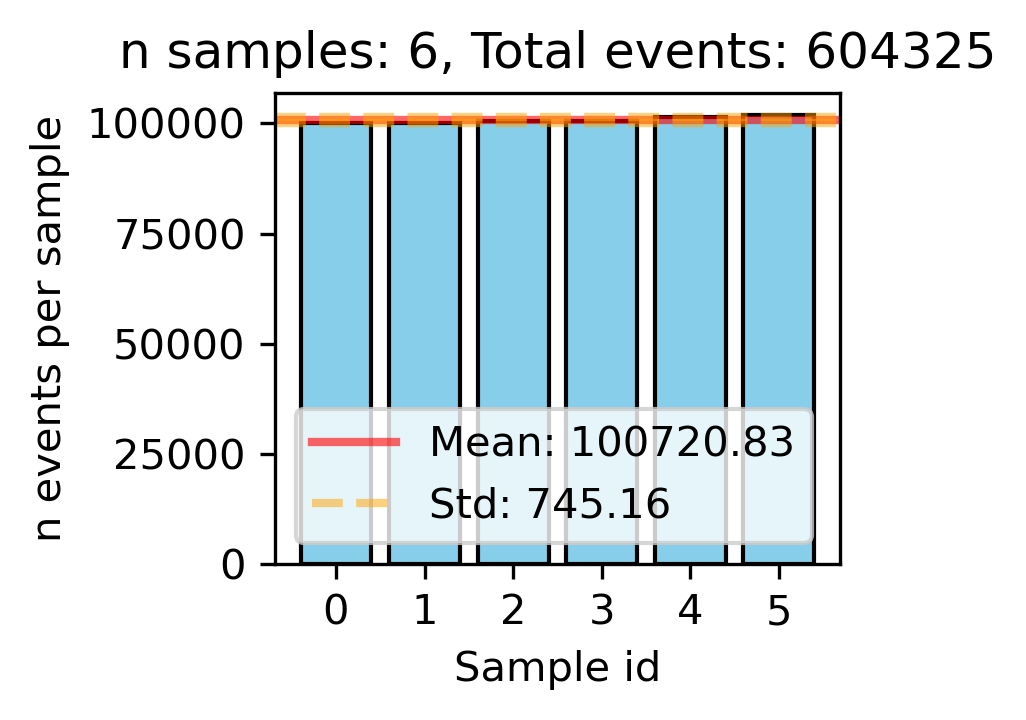

# Compensation log:
             filename                               logs
0  BLAST110_25_P1.fcs  compensation applied successfully
1  BLAST110_50_P1.fcs  compensation applied successfully
2  BLAST110_57_P1.fcs  compensation applied successfully
3  BLAST110_67_P1.fcs  compensation applied successfully
4  BLAST110_77_P1.fcs  compensation applied successfully
5  BLAST110_85_P1.fcs  compensation applied successfully


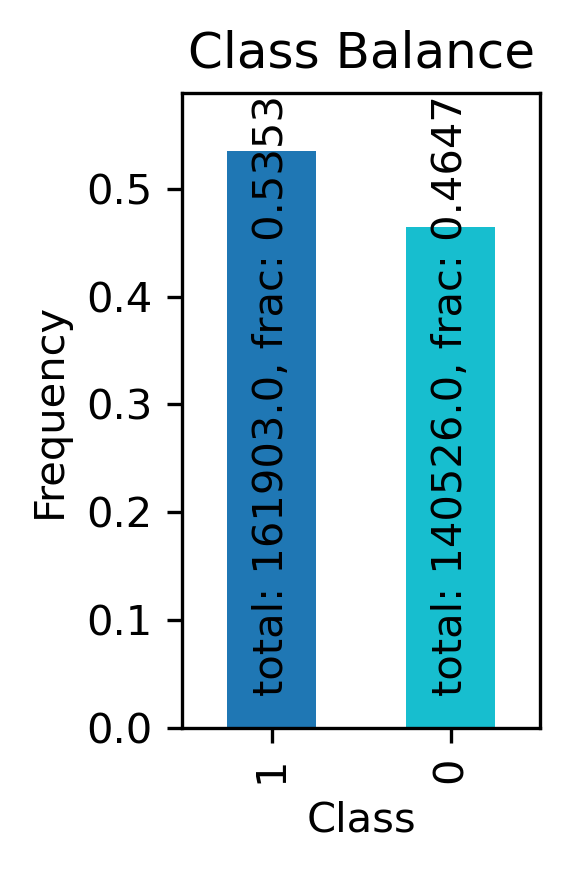

In [348]:

# Align channel names across samples, use 1st sample as reference
# Note: Harmonize channel names across samples by using the 1st file as reference for all others. Assume same channel order across samples.
fdm.align_channel_names(reference_channel_names=0)

# Check whether channel names were consistent across all samples
fdm.check_og_channel_names_df()

# Print the channel names
adata = fdm.anndata_list_[0]
print(f'# Channel names:\n{adata.var.index.tolist()}\n')

# Check the sample sizes
fdm.check_sample_sizes()
fig, ax = plt.subplots(figsize=(3, 2.5), dpi=300)
fdm.plot_sample_size_df(sample_size_df=fdm.sample_sizes_, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Apply compensation
fdm.sample_wise_compensation()
print(f'# Compensation log:\n{fdm.compensation_log_}')

# Apply preprocessing transformation, choose arcsinh with a cofactor of 150, save non-transformed data to layer 'raw'
fdm.sample_wise_preprocessing(flavour='arcsinh', save_raw_to_layer='raw', cofactor=150)

# Perform train test split
fdm.perform_data_split(data_split=(0.5, 0.5), filename_data_split='workflow_supervised_data_split.csv', random_state=41)

# Check the class balance in the training set
class_balance_df = fdm.check_class_balance(data_set='train', label_key='Blast')
fig, ax = plt.subplots(figsize=(2, 3), dpi=300)
fdm.plot_class_balance_df(class_balance_df=class_balance_df, ax=ax)
fig.tight_layout()
plt.show()
plt.close(fig)

# Downsample the samples in the training set to 1000 events per sample. Set stratified=True to ensure preservation of class balances
# Note: Aggressive downsampling is done for faster MLP and SOM classifier training and faster UMAP and t-SNE computation. In practice more events per sample should be retained.
downsampling_bools, _ = fdm.sample_wise_downsampling(data_set='train',  target_num_events=1000, stratified=True, label_key='Blast')



### 4.) Classifier training
Train the MLP and  SOM classifier (supervised)

    100% [===================================================]
# Number of events in training set: 2700, Number of events in validation set: 300
# Early stopping was triggered at epoch 38


Time for epoch 1: 0.0592 Time for epoch 2: 0.05504 Time for epoch 3: 0.04887 Time for epoch 4: 0.05635 Time for epoch 5: 0.04762 Time for epoch 6: 0.04839 Time for epoch 7: 0.05108 Time for epoch 8: 0.02091 Time for epoch 9: 0.03064 Time for epoch 10: 0.02924 Time for epoch 11: 0.02291 Time for epoch 12: 0.01113 Time for epoch 13: 0.0253 Time for epoch 14: 0.03771 Time for epoch 15: 0.03833 Time for epoch 16: 0.00468 Time for epoch 17: 0.001669 Time for epoch 18: 0.001179 Time for epoch 19: 0.001069 Time for epoch 20: 0.001085 

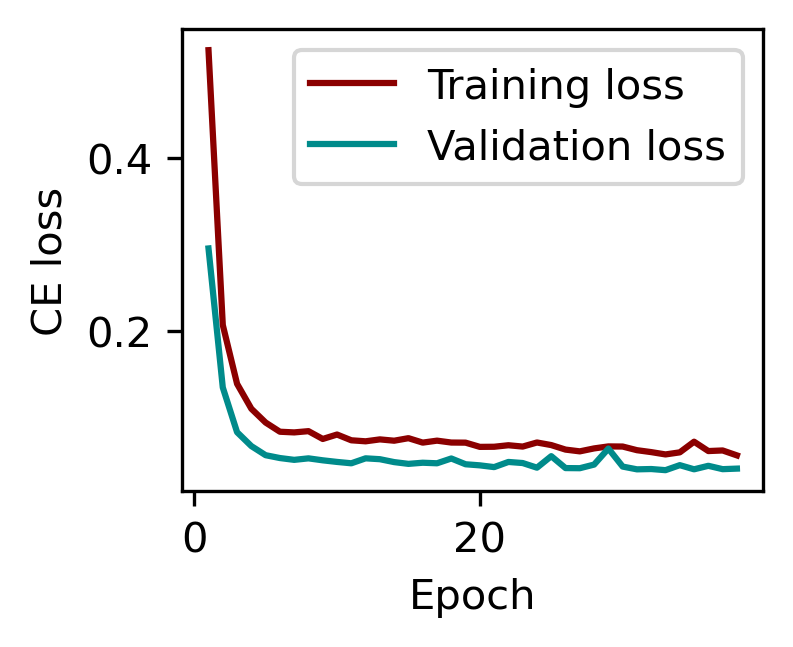

In [349]:
# Extract concatenated and shuffled data matrix for model training
# Note: Generate a data Pytorch DataLoader with batch_size=-1 (meaning all events), and extract the 1st batch.
channels = ['FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45']
data_loader = fdm.get_data_loader(
    data_set='train',
    label_key='Blast',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train, y_train = next(iter(data_loader))


# Instantiate the MLP classifier
n_epochs = 200
mlp_clf = MLPClassifier(
    layer_sizes=(128, 64, 32),
    n_epochs=n_epochs,
    optimizer_params={'lr': 0.001},
    data_loader_params={'batch_size': 128, 'shuffle': True, 'num_workers': 1},
    validation_fraction=0.1,
    early_stopping=True,
    device='cuda:0' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Fit
mlp_clf.fit(X=x_train, y=y_train)

# Save
mlp_clf.save(filepath=SAVE_PATH, filename='workflow_supervised_mlp_classifier.pkl')

# Instantiate the SOM classifier
som_clf = SOMClassifier(
    som_topology='planar',
    som_grid_type='rectangular',
    som_dimensions=(10, 10),
    neighborhood='gaussian',
    gaussian_neighborhood_sigma=0.1,
    initialization='pca',
    n_epochs=20,
    radius_0=-0.5,
    radius_n=0.1,
    radius_cooling='exponential',
    learning_rate_0=0.1,
    learning_rate_n=0.001,
    learning_rate_decay='exponential',
    unlabeled_label=-999,
    verbosity=1
)

# Fit
som_clf.fit(X=x_train, y=y_train)

# Save
som_clf.save(filepath=SAVE_PATH, filename='workflow_supervised_som_classifier.pkl')

# Plot losses from MLP training
tl = mlp_clf.training_log_
print(f'# Number of events in training set: {tl.pop('num_events_train')}, Number of events in validation set: {tl.pop('num_events_val')}')
loss_df = pd.DataFrame(tl)
n_epochs_trained = loss_df.shape[0]
if n_epochs_trained < n_epochs:
    print(f'# Early stopping was triggered at epoch {n_epochs_trained}')
x_vals = np.array(list(range(1, n_epochs_trained + 1)))
fig, ax = plt.subplots(figsize=(2.5, 2.0), dpi=300)
ax.plot(
    x_vals, loss_df['training_loss'].to_numpy(),
    color='darkred',
    label='Training loss'
)
ax.plot(
    x_vals, loss_df['validation_loss'].to_numpy(),
    color='darkcyan',
    label='Validation loss'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('CE loss')
ax.legend()
plt.show()
plt.close(fig)



### 4.) Inference
Previously unseen samples are gated using the MLP classifier and/or the SOM classifier.

Here the samples set aside for testing beforehand are used. In practice, one would typically load the saved classifier models and create a new ``FlowDataManager`` instance to load and process the inference samples.

```python
from flagx.io import FlowDataManager
from flagx.gating import MLPClassifier, SOMClassifier

# Load classifier models
mlp_clf = MLPClassifier.load(filename='/path/to/saved/mlp_model')
som_clf = SOMClassifier.load(filename='/path/to/saved/som_model')

# Load and process data samples
fdm_inference = FlowDataManager(
    data_file_names=['sample0.fcs', 'sample1.fcs', 'sampleN.fcs'],
    data_file_path='/path/to/samples'
)
fdm.load_data_files_to_anndata(reindex=True)

# [...] Perform same processing steps as used for the training data (except for downsampling).
```


In [350]:
y_preds_mlp = []
y_preds_som = []
for adata in fdm.test_data_:
    x = adata[:, channels].X.copy()
    y_preds_mlp.append(mlp_clf.predict(x))
    y_preds_som.append(som_clf.predict(x))


### 5.) Export

In [351]:

# Export
export_to_fcs(
    data_list=fdm.test_data_,
    layer_key='raw',  # Compensated but untransformed data
    sample_wise=False,
    add_columns=[y_preds_mlp, y_preds_som],
    add_columns_names=['pred_mlp', 'pred_som'],
    scale_columns=['pred_mlp', 'pred_som'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames='workflow_supervised_export.fcs'
)


### Performance evaluation

Compute performance metrics to evaluate classifier performance on unseen test data.

In [352]:
method_to_clf = {'mlp': mlp_clf, 'som': som_clf}
rows = []
for i, adata in enumerate(fdm.test_data_):

    sample_name = adata.uns['filename']
    x = adata[:, channels].X.copy()
    y_true = get_labels(adata=adata, label_key='Blast', verbosity=0)

    for method in ['mlp', 'som']:

        y_pred = method_to_clf[method].predict(x)

        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        rows.append({
            'sample_ID': i,
            'sample_name': sample_name,
            'method': method,
            'precision': precision,
            'recall': recall,
            'f1': f1,
        })

res_df = pd.DataFrame(rows).sort_values(by=['method'])

print(f'# Prediction performance:\n{res_df}')


# Prediction performance:
   sample_ID         sample_name method  precision    recall        f1
0          0  BLAST110_50_P1.fcs    mlp   0.817610  0.949318  0.878555
2          1  BLAST110_77_P1.fcs    mlp   0.893647  0.664279  0.762079
4          2  BLAST110_57_P1.fcs    mlp   0.975907  0.945837  0.960637
1          0  BLAST110_50_P1.fcs    som   0.821922  0.921780  0.868991
3          1  BLAST110_77_P1.fcs    som   0.858887  0.891299  0.874793
5          2  BLAST110_57_P1.fcs    som   0.968708  0.997727  0.983003


### 6.) Feedback loop [optional]

To check the quality of the "ground truth" training labels, perform unsupervised dimensionality reduction (SOM, UMAP, t-SNE) on the training data and export the results to FCS (compare unsupervised workflow).

In [353]:

# Extract data matrices (arcsinh transformed and non-transformed) without shuffling and keep track of sample IDs
data_matrices = []
data_matrices_raw = []
y_trues = []
for i, adata in enumerate(fdm.train_data_):
    data_matrices.append(adata[:, channels].X.copy())
    data_matrices_raw.append(adata[:, channels].layers['raw'].copy())
    y_trues.append(get_labels(adata=adata, label_key='Blast', verbosity=0))
x_ordered = np.concatenate(data_matrices, axis=0)
x_ordered_raw = np.concatenate(data_matrices_raw, axis=0)
y_true = np.concatenate(y_trues, axis=0)

# Compute dimensionality reductions
_, x_som, _, _ = som_clf.transform(x_ordered)

reducer_umap = UMAP(n_components=2, n_jobs=-1)
x_umap = reducer_umap.fit_transform(x_ordered)

reducer_tsne = TSNE(n_components=2, n_jobs=-1)
x_tsne = reducer_tsne.fit_transform(x_ordered)

# Transform into correct format for export
x_som0s = []
x_som1s = []
x_umap0s = []
x_umap1s = []
x_tsne0s = []
x_tsne1s = []
starting_idx = 0
for x in data_matrices:
    n_events = x.shape[0]
    x_som_current = x_som[starting_idx:starting_idx + n_events]
    x_umap_current = x_umap[starting_idx:starting_idx + n_events]
    x_tsne_current = x_tsne[starting_idx:starting_idx + n_events]
    x_som0s.append(x_som_current[:, 0])
    x_som1s.append(x_som_current[:, 1])
    x_umap0s.append(x_umap_current[:, 0])
    x_umap1s.append(x_umap_current[:, 1])
    x_tsne0s.append(x_tsne_current[:, 0])
    x_tsne1s.append(x_tsne_current[:, 1])
    starting_idx += n_events

# Export
export_to_fcs(
    data_list=fdm.train_data_,
    layer_key='raw',
    sample_wise=False,
    add_columns=[
        y_trues,
        x_som0s, x_som1s,
        x_umap0s, x_umap1s,
        x_tsne0s, x_tsne1s,
    ],
    add_columns_names=['Blast', 'SOM1', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2'],
    scale_columns=['Blast', 'SOM2', 'UMAP1', 'UMAP2', 'TSNE1', 'TSNE2'],
    val_range=(0.0, 2.0**20),
    keep_unscaled=False,
    save_path=SAVE_PATH,
    save_filenames='workflow_supervised_export_feedback.fcs',
)


### 6.) Feedback loop [optional] cont.

The labels of training data can be validated and refined by jointly analyzing the learned 2D data representations (**A**-**C**) and classical gating scatter plots (**D**-**F**) using established analysis software tools such as Kaluza.


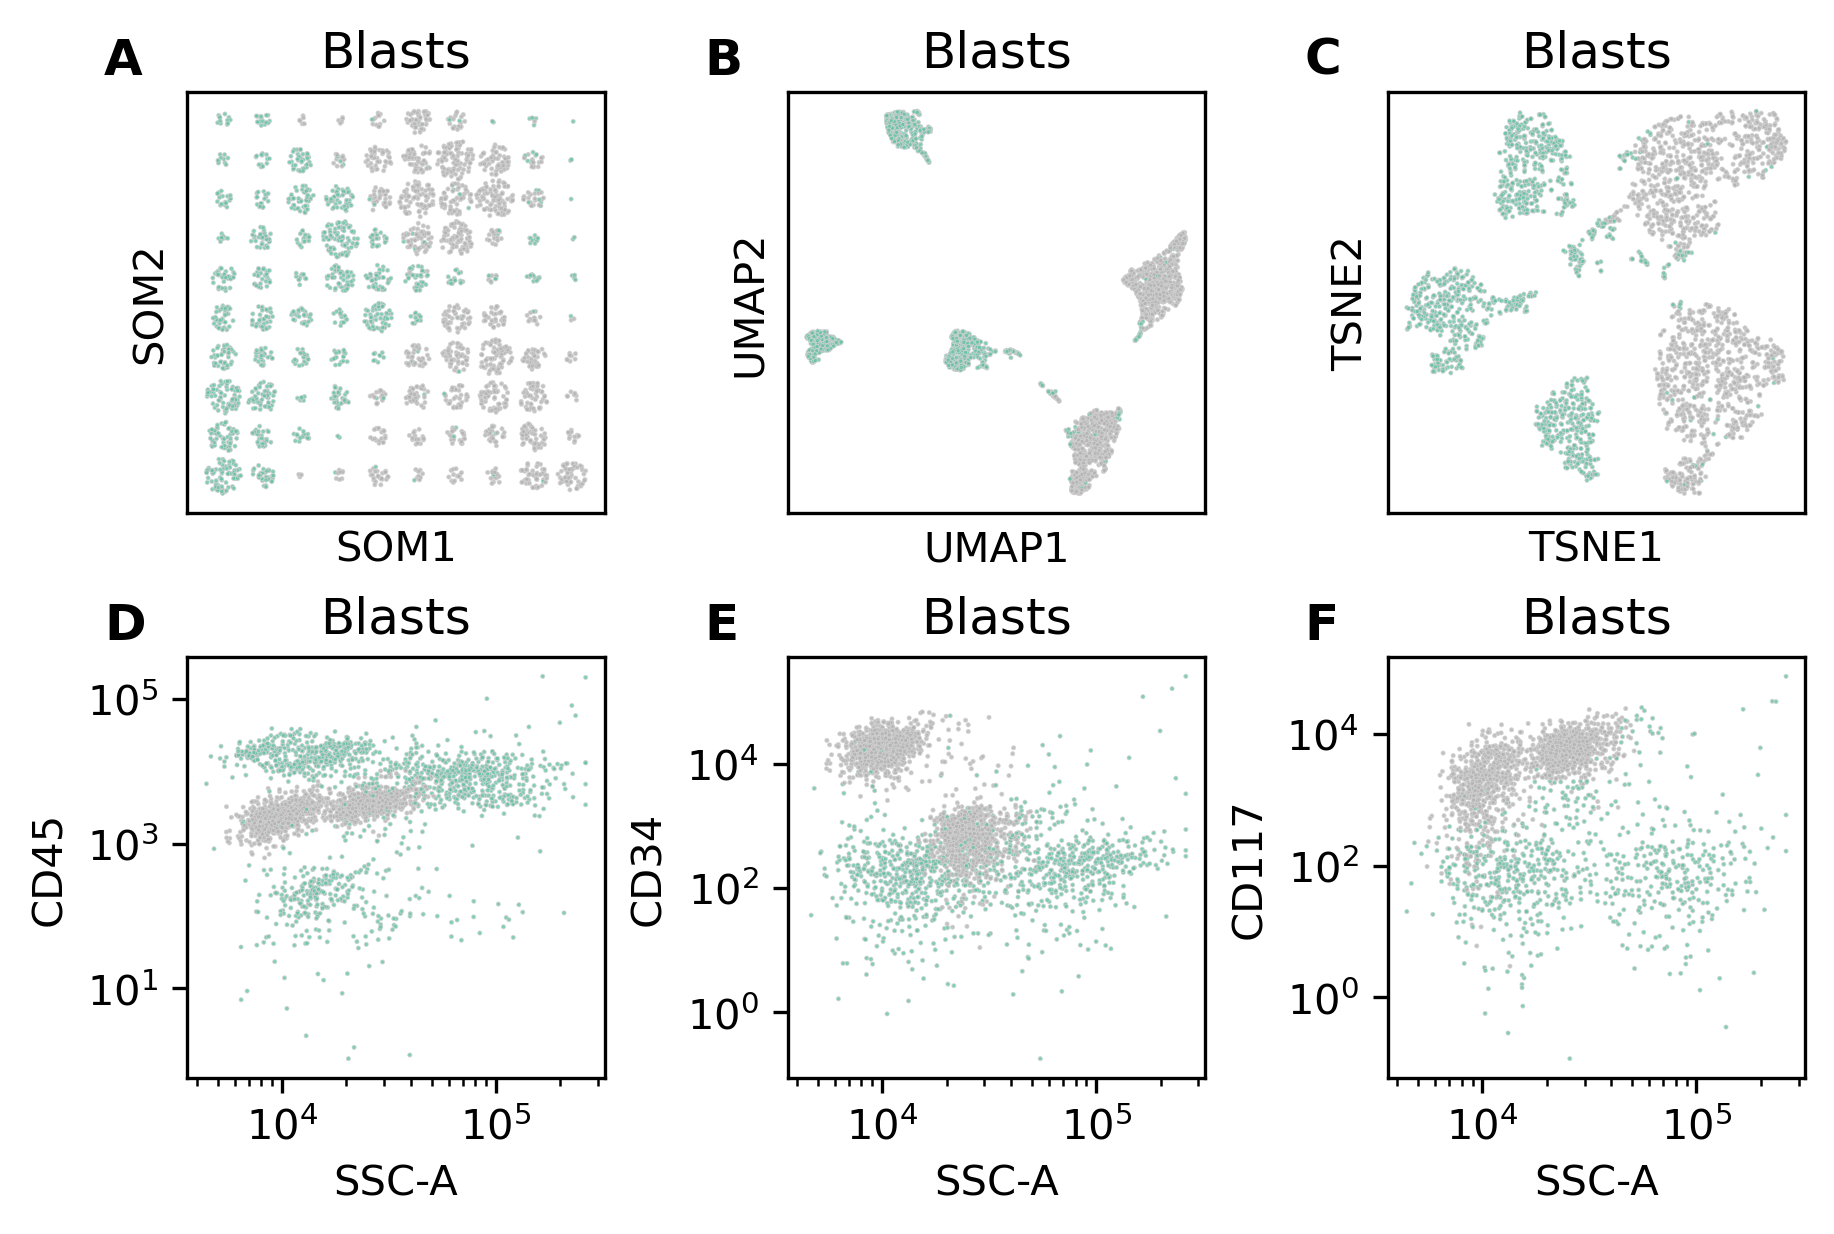

In [354]:

x_ordered_raw_df = pd.DataFrame(x_ordered_raw, columns=channels)

fig, axd = plt.subplot_mosaic(
    '''
    ABC
    DEF
    ''',
    figsize=(6, 4),
    dpi=300,
    constrained_layout=True,
)

marker_size = 1.0

for key, name, x in zip(list('ABC'), ['SOM', 'UMAP', 'TSNE'], [x_som, x_umap, x_tsne]):

    ax = axd[key]
    ax.scatter(
        x[:, 0],
        x[:, 1],
        s=marker_size,
        c=y_true,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(f'{name}1')
    ax.set_ylabel(f'{name}2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Blasts')

# 'FSC-A', 'SSC-A', 'CD7', 'CD56', 'CD34', 'CD117', 'CD33', 'HLA-DR', 'CD13 BV421', 'CD45 KO'
marker_combinations = [('SSC-A', 'CD45'), ('SSC-A', 'CD34'), ('SSC-A', 'CD117')]

for key, (marker0, marker1), in zip(list('DEF'), marker_combinations):
    ax = axd[key]
    ax.scatter(
        x_ordered_raw_df[marker0].to_numpy(),
        x_ordered_raw_df[marker1].to_numpy(),
        s=marker_size,
        c=y_true,
        cmap='Set2',
        edgecolors='lightgrey',
        linewidths=0.2,
        alpha=0.8,
    )
    ax.set_xlabel(marker0)
    ax.set_ylabel(marker1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(False)
    ax.set_title('Blasts')

for label, ax in axd.items():
    trans = mtransforms.ScaledTranslation(-20 / 72, 7 / 72, fig.dpi_scale_trans)
    ax.text(0.0, 0.95, label, transform=ax.transAxes + trans, fontsize=12, va='bottom', fontfamily='sans-serif', fontweight='bold')

plt.show()

### 6.) Feedback loop [optional] cont.

Here, we skip the manual label refinement step and instead emulate it using the learned data representation of the SOM classifiers SOM component.

Each event is assigned the majority label of its best matching unit as a new ground truth label. This is equivalent to:

- defining a gate around all SOM units in (**A**) with majority class green='Blast' to delineate the blast population,
- or using the SOM classifiers prediction on for the training data as the new ground truth .


In [355]:
# Add refined labels
for i, adata in enumerate(fdm.train_data_):
    x = adata[:, channels].X.copy()
    y_pred_som = som_clf.predict(x)
    y_pred = y_pred_som

    y_pred_mlp = mlp_clf.predict(x)
    y_pred = y_pred_mlp * y_pred_som

    adata.obs['blast_refined'] = y_pred

    fdm.train_data_[i] = adata


### 6.) Feedback loop [optional] cont.

Retrain the classifiers

# Number of events in training set: 2700, Number of events in validation set: 300
# Early stopping was triggered at epoch 14


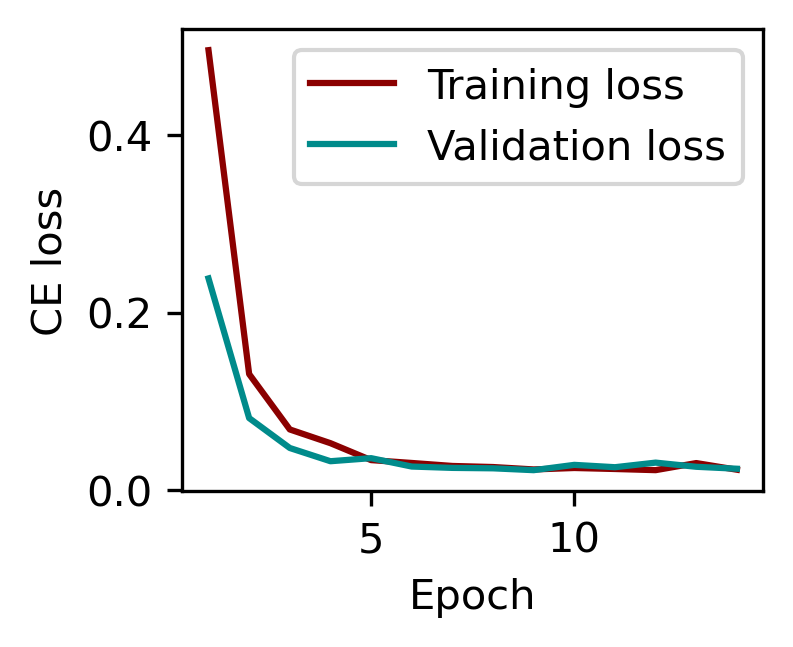

In [356]:

data_loader_refined = fdm.get_data_loader(
    data_set='train',
    label_key='blast_refined',
    channels=channels,
    batch_size=-1,
    shuffle=True,
    return_data_loader='np_array',
)
x_train_refined, y_train_refined = next(iter(data_loader_refined))

n_epochs = 200
mlp_clf_refined = MLPClassifier(
    layer_sizes=(128, 64, 32),
    n_epochs=n_epochs,
    optimizer_params={'lr': 0.001},
    data_loader_params={'batch_size': 128, 'shuffle': True, 'num_workers': 1},
    validation_fraction=0.1,
    early_stopping=True,
    device='cuda:0' if torch.cuda.is_available() else 'cpu',
    verbosity=0
)

# Fit
mlp_clf_refined.fit(X=x_train_refined, y=y_train_refined)

# Plot losses from MLP training
tl = mlp_clf_refined.training_log_
print(f'# Number of events in training set: {tl.pop('num_events_train')}, Number of events in validation set: {tl.pop('num_events_val')}')
loss_df = pd.DataFrame(tl)
n_epochs_trained = loss_df.shape[0]
if n_epochs_trained < n_epochs:
    print(f'# Early stopping was triggered at epoch {n_epochs_trained}')
x_vals = np.array(list(range(1, n_epochs_trained + 1)))
fig, ax = plt.subplots(figsize=(2.5, 2.0), dpi=300)
ax.plot(
    x_vals, loss_df['training_loss'].to_numpy(),
    color='darkred',
    label='Training loss'
)
ax.plot(
    x_vals, loss_df['validation_loss'].to_numpy(),
    color='darkcyan',
    label='Validation loss'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('CE loss')
ax.legend()
plt.show()
plt.close(fig)



### 6.) Feedback loop [optional] cont.

Compare performance metrics between original and refined training labels.

**Caveats**:
- In this small demonstration only a very limited number of samples is used, for training and testing.
- Manual label refinement was emulated using the SOM.
- Performance metrics are computed w.r.t. the original "ground truth" labels. However, those may not be reliable as well.

As a consequence an improvement of "refined" over "original" training labels may not be achieved in each training run.

In [357]:

rows = []
for i, adata in enumerate(fdm.test_data_):

    sample_name = adata.uns['filename']
    x = adata[:, channels].X.copy()
    y_true = get_labels(adata=adata, label_key='Blast', verbosity=0)

    y_pred_refined = mlp_clf_refined.predict(x)

    precision = precision_score(y_true, y_pred_refined)
    recall = recall_score(y_true, y_pred_refined)
    f1 = f1_score(y_true, y_pred_refined)

    rows.append({
        'sample_ID': i,
        'sample_name': sample_name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

res_df_refined = pd.DataFrame(rows).sort_values('sample_ID')
res_df_base = res_df[res_df['method'] == 'mlp'].sort_values('sample_ID')

merged = res_df_base.merge(
    res_df_refined,
    on=['sample_ID', 'sample_name'],
    suffixes=('_base', '_refined')
)

for metric in ['precision', 'recall', 'f1']:
    merged[f'delta_{metric}'] = merged[f'{metric}_refined'] - merged[f'{metric}_base']

print(f"# Delta per sample:\n{merged[['method', 'sample_ID', 'delta_precision', 'delta_recall', 'delta_f1']]}")


# Delta per sample:
  method  sample_ID  delta_precision  delta_recall  delta_f1
0    mlp          0         0.001265     -0.005058 -0.001446
1    mlp          1         0.018130      0.064332  0.047889
2    mlp          2        -0.006980      0.050370  0.021741
